## Devoir maison sur les élections présidentielles de 2022



Import des packages nécessaires et des données 

In [1]:
import pandas as pd
!pip install great-tables
from great_tables import GT

df=pd.read_csv('https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb')
df.head()

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------------------------------------- -- 1.3/1.4 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.6 MB/s  0:00:00
   ---------------------------------------- 0.0/607.2 kB ? eta -:--:--
   ---------------------------------------- 607.2/607.2 kB 4.4 MB/s  0:00:00

   ---------------------------------------- 0/5 [commonmark]
   ---------------------------------------- 0/5 [commonmark]
   -------- ------------------------------- 1/5 [importlib-resources]
   -------- ------------------------------- 1/5 [importlib-resources]
   ---------------- ----------------------- 2/5 [htmltools]
   -------------------------------- ------- 4/5 [great-tables]
   -------------------------------- ------- 4/5 [great-tables]
   -------------------------------- ------- 4/5 [great-tables]
   -------------------------------- ------- 4/5 [grea

C:\Users\matte\AppData\Local\Temp\ipykernel_22016\2401630193.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb')


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


### Question 1

In [ ]:
#Première partie de la question
df=pd.read_csv('https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb', low_memory=False)
df["code_commune"] = df["code_departement"].astype(str) + df["code_commune"].astype(str).str.zfill(3)

#df[df['libelle_commune'] == 'Montrouge']['code_commune'].values[0]

#Deuxième partie de la question
df["candidat"] = df["prenom"] + " " + df["nom"]
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


### Question 2

In [3]:
df_votes_exprimes = df[~df["candidat"].str.contains("BLANC|NUL|ABSTENTION", case=False, na=False)]

candidats = df_votes_exprimes["candidat"].nunique()

print(f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


### Question 3 (sans great_table, tableau avec un affichage print simple)

In [4]:
votes_nationaux = (
    df_votes_exprimes
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'Nombre votes (total)'})
)

total_exprimes = votes_nationaux['Nombre votes (total)'].sum()

votes_nationaux['Score (% de votes exprimés)'] = (
    votes_nationaux['Nombre votes (total)'] / total_exprimes * 100
).round(2)

votes_nationaux = votes_nationaux.sort_values('Nombre votes (total)', ascending=False)

print(votes_nationaux.to_string(index=False))

             candidat  Nombre votes (total)  Score (% de votes exprimés)
      Emmanuel MACRON               9783058                        27.85
        Marine LE PEN               8133828                        23.15
   Jean-Luc MÉLENCHON               7712520                        21.95
         Éric ZEMMOUR               2485226                         7.07
     Valérie PÉCRESSE               1679001                         4.78
        Yannick JADOT               1627853                         4.63
        Jean LASSALLE               1101387                         3.13
       Fabien ROUSSEL                802422                         2.28
Nicolas DUPONT-AIGNAN                725176                         2.06
         Anne HIDALGO                616478                         1.75
      Philippe POUTOU                268904                         0.77
     Nathalie ARTHAUD                197094                         0.56


### Question 3 (avec great_tables)

In [5]:
table_votes_2022 = (
    GT(votes_nationaux)
    .tab_header(
        title=" Résultats du premier tour (2022)",
        subtitle="Scores nationaux des candidats à l'élection présidentielle"
    )
    .fmt_number(
        columns="Nombre votes (total)",
        decimals=0,
        use_seps=True,
        sep_mark=" "
    )
    .fmt_number(
        columns="Score (% de votes exprimés)",
        decimals=2
    )
    .cols_label(
        candidat="Candidat",
        **{
            "Nombre votes (total)": "Nombre de votes",
            "Score (% de votes exprimés)": "Score (%)"
        }
    )
)

table_votes_2022

GT(_tbl_data=                 candidat  Nombre votes (total)  Score (% de votes exprimés)
1         Emmanuel MACRON               9783058                        27.85
5           Marine LE PEN               8133828                        23.15
4      Jean-Luc MÉLENCHON               7712520                        21.95
11           Éric ZEMMOUR               2485226                         7.07
9        Valérie PÉCRESSE               1679001                         4.78
10          Yannick JADOT               1627853                         4.63
3           Jean LASSALLE               1101387                         3.13
2          Fabien ROUSSEL                802422                         2.28
7   Nicolas DUPONT-AIGNAN                725176                         2.06
0            Anne HIDALGO                616478                         1.75
8         Philippe POUTOU                268904                         0.77
6        Nathalie ARTHAUD                197094                         0.56, _body=<great_tables._gt_data.Body object at 0x0000025BB002DE80>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre de votes', column_align='right', column_width=None), ColInfo(var='Score (% de votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000025BB57F2D20>, _spanners=Spanners([]), _heading=Heading(title=' Résultats du premier tour (2022)', subtitle="Scores nationaux des candidats à l'élection présidentielle", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000025BB064FDD0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000025BB94E5AF0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000025BB1F3BFB0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000025BB4258B00>, <great_tables._gt_data.FormatInfo object at 0x0000025BB42588F0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_borde

### Question 4

In [6]:
score_departements = df_votes_exprimes.groupby(
    ["code_departement", "candidat"])["voix"].sum().reset_index()
total_dep = score_departements.groupby("code_departement")["voix"].sum().reset_index()
total_dep = total_dep.rename(columns={"voix": "total_dep"})
score_departements = score_departements.merge(total_dep, on="code_departement")
score_departements["score"] = (score_departements["voix"] / score_departements["total_dep"] * 100 ).round(2)
score_departements = score_departements.drop(columns="total_dep")
score_departements = score_departements.sort_values(["voix", "score"], ascending=False)
score_departements["score"] = score_departements["score"].astype(str) + " %"
score_departements

,code_departement,candidat,voix,score
713,59,Marine LE PEN,373127,29.27 %
901,75,Emmanuel MACRON,372820,35.34 %
709,59,Emmanuel MACRON,336138,26.37 %
904,75,Jean-Luc MÉLENCHON,317372,30.08 %
749,62,Marine LE PEN,305816,38.68 %
...,...,...,...,...
1232,977,Philippe POUTOU,27,1.02 %
1206,975,Nathalie ARTHAUD,22,0.81 %
1202,975,Fabien ROUSSEL,19,0.7 %
1226,977,Fabien ROUSSEL,14,0.53 %


In [7]:
#Vérification pour l'Aude
score_departements[score_departements["code_departement"] == "11"]

,code_departement,candidat,voix,score
125,11,Marine LE PEN,64027,30.14 %
121,11,Emmanuel MACRON,43104,20.29 %
124,11,Jean-Luc MÉLENCHON,42039,19.79 %
131,11,Éric ZEMMOUR,18434,8.68 %
123,11,Jean LASSALLE,12382,5.83 %
129,11,Valérie PÉCRESSE,7350,3.46 %
130,11,Yannick JADOT,6322,2.98 %
120,11,Anne HIDALGO,6166,2.9 %
122,11,Fabien ROUSSEL,5622,2.65 %
127,11,Nicolas DUPONT-AIGNAN,4206,1.98 %


### Question 5

In [8]:
votes_france_entiere = votes_nationaux.rename(columns={
    "voix": "Nombre votes (total)",
    "score": "Score (% de votes exprimés)"
})

score_departements = score_departements.merge(
    votes_nationaux[["candidat", "Nombre votes (total)", "Score (% de votes exprimés)"]].rename(columns={
        "Nombre votes (total)": "votes_national",
        "Score (% de votes exprimés)": "score_national"
    }),
    on="candidat"
)
score_departements["score_national"] = score_departements["score_national"] .astype(str) + " %"
score_departements

,code_departement,candidat,voix,score,votes_national,score_national
0,59,Marine LE PEN,373127,29.27 %,8133828,23.15 %
1,75,Emmanuel MACRON,372820,35.34 %,9783058,27.85 %
2,59,Emmanuel MACRON,336138,26.37 %,9783058,27.85 %
3,75,Jean-Luc MÉLENCHON,317372,30.08 %,7712520,21.95 %
4,62,Marine LE PEN,305816,38.68 %,8133828,23.15 %
...,...,...,...,...,...,...
1291,977,Philippe POUTOU,27,1.02 %,268904,0.77 %
1292,975,Nathalie ARTHAUD,22,0.81 %,197094,0.56 %
1293,975,Fabien ROUSSEL,19,0.7 %,802422,2.28 %
1294,977,Fabien ROUSSEL,14,0.53 %,802422,2.28 %


In [9]:
#Vérification pour l'Aude
score_departements[score_departements["code_departement"] == "11"]

,code_departement,candidat,voix,score,votes_national,score_national
162,11,Marine LE PEN,64027,30.14 %,8133828,23.15 %
234,11,Emmanuel MACRON,43104,20.29 %,9783058,27.85 %
245,11,Jean-Luc MÉLENCHON,42039,19.79 %,7712520,21.95 %
414,11,Éric ZEMMOUR,18434,8.68 %,2485226,7.07 %
541,11,Jean LASSALLE,12382,5.83 %,1101387,3.13 %
726,11,Valérie PÉCRESSE,7350,3.46 %,1679001,4.78 %
770,11,Yannick JADOT,6322,2.98 %,1627853,4.63 %
777,11,Anne HIDALGO,6166,2.9 %,616478,1.75 %
812,11,Fabien ROUSSEL,5622,2.65 %,802422,2.28 %
901,11,Nicolas DUPONT-AIGNAN,4206,1.98 %,725176,2.06 %


### Question 6

In [10]:
score_departements["surrepresentation"] = (
    (score_departements["score"].str.replace(" %", "").astype(float)
     - score_departements["score_national"] .str.replace(" %", "").astype(float))
    / score_departements["score_national"] .str.replace(" %", "").astype(float) * 100
).round(2)

score_departements["surrepresentation"] = score_departements["surrepresentation"].astype(str) + " (%)"

score_departements

,code_departement,candidat,voix,score,votes_national,score_national,surrepresentation
0,59,Marine LE PEN,373127,29.27 %,8133828,23.15 %,26.44 (%)
1,75,Emmanuel MACRON,372820,35.34 %,9783058,27.85 %,26.89 (%)
2,59,Emmanuel MACRON,336138,26.37 %,9783058,27.85 %,-5.31 (%)
3,75,Jean-Luc MÉLENCHON,317372,30.08 %,7712520,21.95 %,37.04 (%)
4,62,Marine LE PEN,305816,38.68 %,8133828,23.15 %,67.08 (%)
...,...,...,...,...,...,...,...
1291,977,Philippe POUTOU,27,1.02 %,268904,0.77 %,32.47 (%)
1292,975,Nathalie ARTHAUD,22,0.81 %,197094,0.56 %,44.64 (%)
1293,975,Fabien ROUSSEL,19,0.7 %,802422,2.28 %,-69.3 (%)
1294,977,Fabien ROUSSEL,14,0.53 %,802422,2.28 %,-76.75 (%)


### Question 7

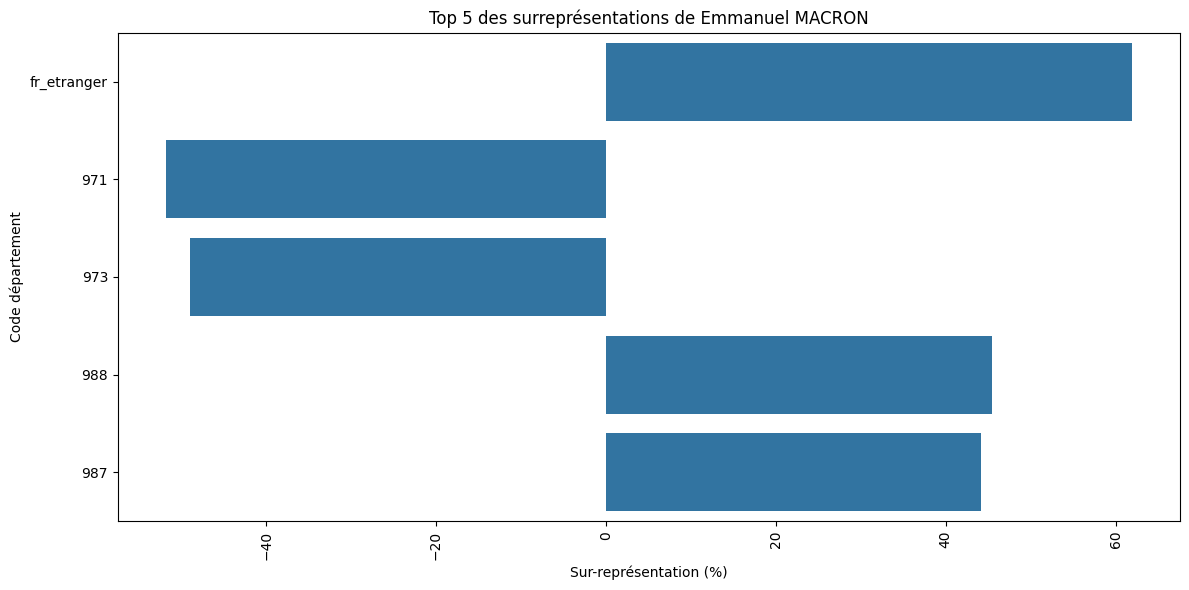

In [25]:
def graphique_surrepresentation(candidat):
    import matplotlib.pyplot as plt
    import seaborn as sns

    data_candidat = score_departements[score_departements["candidat"] == candidat].copy()
    data_candidat["surrepresentation"] = data_candidat["surrepresentation"].str.replace(" (%)", "", regex=False).astype(float)
    data_candidat["surrepresentation_abs"] = data_candidat["surrepresentation"].abs()
    data_candidat = data_candidat.sort_values("surrepresentation_abs", ascending=False)
    data_candidat = data_candidat.head(5)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x="surrepresentation", y="code_departement", data=data_candidat)
    plt.title(f"Top 5 des surreprésentations de {candidat}")
    plt.xlabel("Sur-représentation (%)")
    plt.ylabel("Code département")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

graphique_surrepresentation("Emmanuel MACRON")

### Question 8

In [27]:
!pip install cartiflette

  Using cached cartiflette-0.1.9-py3-none-any.whl.metadata (3.0 kB)
  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached platformdirs-4.9.4-py3-none-any.whl.metadata (4.7 kB)
  Using cached requests_cache-1.3.1-py3-none-any.whl.metadata (9.4 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached pyogrio-0.12.1-cp312-cp312-win_amd64.whl.metadata (6.0 kB)
  Using cached pyproj-3.7.2-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp312-cp312-win_amd64.whl.metadata (7.1 kB)
  Using cached cattrs-26.1.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached cartiflette-0.1.9-py3-none-any.whl (6.8 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached platformdirs-4.9.4-py3-none-any.whl (21 kB)
Using cached pyogrio-0.12.1-cp312-cp312-win_amd64.whl (22.9 MB)
Using c

ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: 'C:\\Users\\matte\\Documents\\Python\\Lib\\site-packages\\shapely-2.1.2.dist-info\\INSTALLER'
Consider using the `--user` option or check the permissions.



In [28]:
from cartiflette import carti_download
departement_borders = carti_download(
 values = ["France"],
 crs = 4326,
 borders = "DEPARTEMENT",
 vectorfile_format="geojson",
 simplification=50,
 filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
 source="EXPRESS-COG-CARTO-TERRITOIRE",
 year=2022)

In [ ]:
departement_borders.head()

,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry
0,43,France,Haute-Loire,227570,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.89745 45.35699, 3.89691 45.35631, ..."
1,65,France,Hautes-Pyrénées,229567,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.09705 43.5822, -0.09642 43...."
2,29,France,Finistère,915090,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.97907 47.70396, -3.98004 47..."
3,22,France,Côtes-d'Armor,600582,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.20174 48.85198, -3.20193 48..."
4,38,France,Isère,1271166,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((5.10149 45.81356, 5.09828 45.80627, ..."


In [34]:
jointure = departement_borders.merge(score_departements, left_on="INSEE_DEP", right_on="code_departement", how="left")

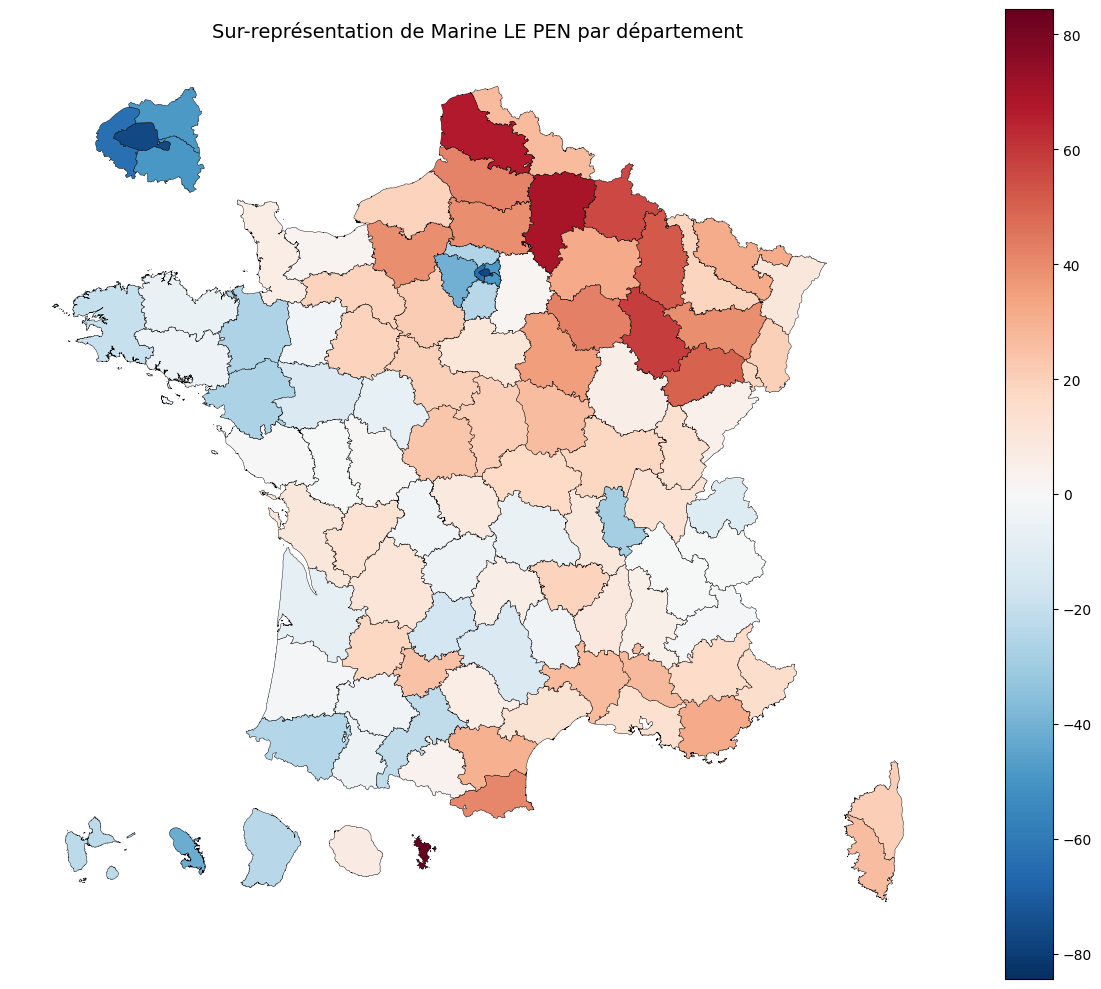

In [39]:
import matplotlib.pyplot as plt

def score_candidat(candidat, data):
    data_candidat = data[data["candidat"] == candidat].copy()
    return data_candidat


def carte_surrepresentation(candidat):
    # Filtrer et préparer les données
    data = score_candidat(candidat, jointure)
    data["surrepresentation"] = data["surrepresentation"].str.replace(" (%)", "", regex=False).astype(float)
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    vmax = data["surrepresentation"].abs().max()

    data.plot(
        column="surrepresentation",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        legend=True,
        edgecolor="black",
        linewidth=0.3,
        ax=ax
    )
    
    ax.set_title(f"Sur-représentation de {candidat} par département", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

carte_surrepresentation("Marine LE PEN")